In [1]:
import pandas as pd
import numpy as np
import cv2
import os
import shutil
import re
import tifffile
import matplotlib.pyplot as plt
import random
from scipy.signal import convolve2d
DSET_PATH = ".\\dset"
OUT_PATH = ".\\dset_out"
LR_NAME = "WF_raw.tif"
BRIGHT_SHIFT = "BS"

In [2]:
#gather all image data, aggregate into a single folder. Label images by type, and cell #.
#place HR, and LR in seperate folders.
#build list of file names
kernel = np.asarray(
    [[1/9,1/9,1/9],
    [1/9,1/9,1/9],
    [1/9,1/9,1/9]]
)

signal_counts = [1,3,7,15,25,50,75,100]

class ImgTransform():
    def __init__(self, name):
        self.name = name
    #change the brightness by a scaling value
    #shift the image by a specified angle
    def transformation(self, img, bright_shift=0, rot=0):
        img = img * bright_shift
        rot_matrix = cv2.getRotationMatrix2D((len(img/2),len(img[0])/2), rot, 1)
        img = cv2.warpAffine(img, rot_matrix, img.shape)
        return img

class VFlip(ImgTransform):
    def __init__(self, name):
        super(VFlip, self).__init__(name)

    def transformation(self, img, bright_shift=0, rot=0):
        img = np.flipud(img)
        img = super(VFlip, self).transformation(img, bright_shift, rot)
        return img
    
class HFlip(ImgTransform):
    def __init__(self, name):
        super(HFlip, self).__init__(name)

    def transformation(self, img, bright_shift=0, rot=0):
        img = np.fliplr(img)
        img = super(HFlip, self).transformation(img, bright_shift, rot)
        return img

class VHFlip(ImgTransform):
    def __init__(self, name):
        super(VHFlip, self).__init__(name)

    def transformation(self, img, bright_shift=0, rot=0):
        img = np.flipud(img)
        img = np.fliplr(img)
        img = super(VHFlip, self).transformation(img, bright_shift, rot)
        return img
    
class Rot90(ImgTransform):
    def __init__(self, name):
        super(Rot90, self).__init__(name)

    def transformation(self, img, bright_shift=0, rot=0):
        img = np.rot90(img, 1)
        img = super(Rot90, self).transformation(img, bright_shift, rot)
        return img

class Rot270(ImgTransform):
    def __init__(self, name):
        super(Rot270, self).__init__(name)

    def transformation(self, img, bright_shift=0, rot=0):
        img = np.rot90(img, 3)
        img = super(Rot270, self).transformation(img, bright_shift, rot)
        return img        

def get_images(source, count):
    sample_range = range(0,len(source))
    samples = random.sample(sample_range, count)
    return source[samples]

def do_weighted_avg(img_data, kernel=kernel):
    img_data = img_data.astype(np.uint32)
    inverse_stds = np.zeros(img_data.shape)
    for i in range(0,len(img_data)):
        sq_mean = convolve2d(img_data[i]**2, kernel, mode='same', boundary='fill') 
        mean_sq = convolve2d(img_data[i], kernel, mode='same', boundary='fill')**2 
        inverse_stds[i] = 1/np.sqrt(sq_mean - mean_sq)
    avgs = inverse_stds.sum(axis=0)
    res = (inverse_stds * img_data).sum(axis=0)/avgs
    #convert back to uint16
    res = np.clip(res, 0, 65535).astype(np.uint16)
    return res

#output params for transformation
def get_transform_params(param_count: int, bright_max: float, bright_min: float):
    params = []
    for i in range(0, param_count):
        param = bright_min + (bright_max-bright_min) * random.random()
        params.append(np.round(param, 4))
    return params

#assumes you have not appended a postfix to the filename 
def save_img(img_data, filename, path, postfix=".tif"):
    full_name = os.path.join(path,f"{filename}{postfix}")
    tifffile.imwrite(full_name, img_data)

#performs transformation saves to disk to avoid memory load
def do_transforms(base_name: str, base_img, transformations: list[ImgTransform], params: [float], save_path: os.PathLike):    
    #keep 1 unmodified image
    names = []

    #apply transformations, create names for tracking
    for i in range(0,len(transformations)):
        transform = transformations[i]
        img = transform.transformation(base_img.copy(),params[i])
        names.append(f"{base_name}_{transform.name}_{BRIGHT_SHIFT}-{params[i]}")
        save_img(img, names[i], save_path)

    return names
    
def append_to_df(df: pd.DataFrame, lr_names: list[str], hr_names: list[str], transforms: list[str], params: list[float]):
    for i in range(0, len(lr_names)):
        df.loc[len(df),:] = [lr_names[i], hr_names[i], transforms[i], params[i]]

def prepare_images(base_name: str, lr_data, hr_data, transformations: list[ImgTransform], signal_rats: list[int], out_path: os.PathLike, img_pair_csv: pd.DataFrame):
    hr_base_name = base_name + "_HR"
    lr_base_name = base_name + "_LR"

    transform_names = []
    for transform in transformations:
        transform_names.append(transform.name)

    #get brightness shifts in range 0.8 - 1.2 (attentuation/gain factor)
    transform_params = get_transform_params(len(transformations)-1, 1.2, 0.8)
    #add unity
    transform_params.insert(0,1.0)

    hr_names = do_transforms(hr_base_name, hr_data.copy(), transformations, transform_params, out_path)
    for signal in signal_rats:
        #we combine signal where signal is an int, images together to improve SNR
        signal_base_name = f"{lr_base_name}_SNR-{signal}"
        signal_data = get_images(lr_data, signal)
        lr_avged = do_weighted_avg(signal_data)
        lr_names = do_transforms(signal_base_name, lr_avged.copy(), transformations, transform_params, out_path)
        append_to_df(img_pair_csv, lr_names, hr_names, transform_names, transform_params)

def rw_issue(lr_path, hr_path):
    global first 
    if (not os.path.exists(lr_path)):
        return False
    
    if(not os.path.exists(hr_path)):
        return False

    lr = tifffile.imread(lr_path)
    hr = tifffile.imread(hr_path)
    
    if first:
        first = 0
        print(lr.dtype)
        print("sanity visual")
        plt.imshow(lr.mean(axis=0))
        plt.show()
    return lr, hr

<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
C:\Users\tacotortilla\AppData\Local\Temp\ipykernel_47156\2083597273.py:28: SyntaxWarning: invalid escape sequence '\d'
  res = re.match("cell(\d+)",dir)


Scanning: CCPs
uint16
sanity visual


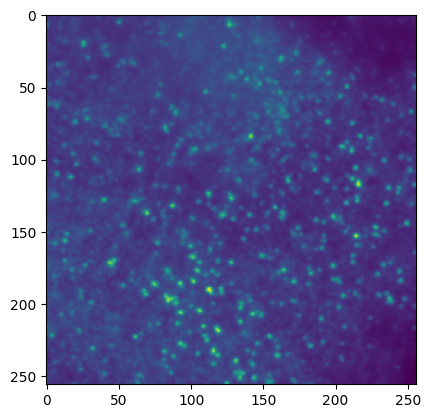

Skipped: data information.txt
Scanning: ER-KDEL
Scanning: ER-sec61β
Scanning: IMM-cox8a
Scanning: Microtubules
Scanning: OMM-tomm20


In [3]:
# Process data
unity = ImgTransform("UNITY")
bs = ImgTransform("BS")
vflip = VFlip("VFLIP")
hflip = HFlip("HFLIP")
vhflip = VHFlip("VHFLIP")
rot90 =  Rot90("ROT90")
rot270 = Rot270("ROT270")
transformations = [unity, bs, vflip, hflip, vhflip, rot90, rot270]

img_path = f".\\{OUT_PATH}\\img_files"
df = pd.DataFrame(columns=["lr_name","hr_name","transformation", "Bright_Shift"])
#create directories
if os.path.exists(OUT_PATH):
    shutil.rmtree(OUT_PATH)
    
os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs(img_path, exist_ok=True)
first = 1
for main_dir in os.listdir(DSET_PATH):
    if (not os.path.isdir(os.path.join(DSET_PATH,main_dir))):
        print(f"Skipped: {main_dir}")
        continue
    else:
        print(f"Scanning: {main_dir}")

    for dir in os.listdir(os.path.join(DSET_PATH,main_dir)):
        res = re.match("cell(\d+)",dir)
        if(res):
            name = f"{main_dir}_c{res.group(1)}"
            lr = os.path.join(DSET_PATH,main_dir,res.group(0),LR_NAME)
            hr = os.path.join(DSET_PATH,main_dir,res.group(0),f"SR{res.group(1)}.tif")
            out = rw_issue(lr, hr)
            if (out):
                lr_data = out[0]
                hr_data = out[1]
            prepare_images(name, lr_data, hr_data, transformations, signal_counts, img_path, df)
            df.to_csv(os.path.join(OUT_PATH, "img_pairs.csv"))
            